# Libraries & Settings


In [3]:
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("AHP, ANP, and DEMATEL structural modeling environment ready.")

AHP, ANP, and DEMATEL structural modeling environment ready.


# Problem Definition - Strategic Vehicle Selection Benchmark


In [4]:
# Alternatives: 3 Vehicles
alternatives = ["Vehicle 1 (V1)", "Vehicle 2 (V2)", "Vehicle 3 (V3)"]

# Main Criteria
main_criteria = ["Price (C1)", "Fuel Consumption (C2)", "Safety (C3)", "Technical (C4)"]

# Sub-criteria (6 Total Operational Criteria for DEMATEL & Synthesis)
sub_criteria = [
    "C1: Price",
    "C2: Fuel Consumption",
    "C31: Body Safety",
    "C32: Airbags",
    "C41: Engine Capacity",
    "C42: Max Speed"
]

print(f"System defined: {len(alternatives)} Alternatives and {len(sub_criteria)} Final Evaluation Criteria.")

System defined: 3 Alternatives and 6 Final Evaluation Criteria.


# MODULE 1 - Analytic Hierarchy Process (AHP)


In [5]:
def ahp_priority_vector(matrix):
    """Computes principal eigenvector and consistency ratio (CR)."""
    n = matrix.shape[0]
    RI_dict = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24}
    
    eigvals, eigvecs = la.eig(matrix)
    max_idx = np.argmax(np.real(eigvals))
    lambda_max = np.real(eigvals[max_idx])
    
    weights = np.real(eigvecs[:, max_idx])
    weights = weights / np.sum(weights)
    if np.any(weights < 0):
        weights = -weights / np.sum(-weights)
        
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0.0
    CR = CI / RI_dict.get(n, 1.32) if n > 2 else 0.0
    return weights, CR

# 1. Main Criteria Pairwise Comparison (4x4)
A_main = np.array([
    [1.0,  2.0,  0.5,  3.0],   # Price vs Fuel, Safety, Tech
    [0.5,  1.0,  0.25, 2.0],   # Fuel
    [2.0,  4.0,  1.0,  4.0],   # Safety
    [0.33, 0.5,  0.25, 1.0]    # Technical
])
w_main, cr_main = ahp_priority_vector(A_main)

# 2. Sub-criteria Local Pairwise Comparisons (2x2 each)
# Safety sub-criteria (Body Safety vs Airbags)
A_safety = np.array([[1.0, 2.0], [0.5, 1.0]])
w_sub_safety, _ = ahp_priority_vector(A_safety)

# Technical sub-criteria (Engine Capacity vs Max Speed)
A_tech = np.array([[1.0, 3.0], [0.3333, 1.0]])
w_sub_tech, _ = ahp_priority_vector(A_tech)

# 3. Global Sub-criteria Weights Synthesis
w_global_sub = np.array([
    w_main[0],                     # C1: Price
    w_main[1],                     # C2: Fuel
    w_main[2] * w_sub_safety[0],   # C31: Body Safety
    w_main[2] * w_sub_safety[1],   # C32: Airbags
    w_main[3] * w_sub_tech[0],     # C41: Engine
    w_main[3] * w_sub_tech[1]      # C42: Max Speed
])
w_global_sub /= np.sum(w_global_sub)

# 4. Alternative Performance Matrices under Each Sub-criterion (3x3 each)
# Format: Rows = V1, V2, V3
local_alt_scores = np.zeros((len(alternatives), len(sub_criteria)))

# Judgments for each criterion (consistent benchmark preferences)
P_C1 = np.array([[1.0, 3.0, 5.0], [0.333, 1.0, 2.0], [0.2, 0.5, 1.0]])  # V1 is cheapest
P_C2 = np.array([[1.0, 2.0, 4.0], [0.5, 1.0, 3.0], [0.25, 0.333, 1.0]]) # V1 lowest fuel
P_C31 = np.array([[1.0, 0.333, 0.2], [3.0, 1.0, 0.5], [5.0, 2.0, 1.0]]) # V3 safest body
P_C32 = np.array([[1.0, 0.5, 0.25], [2.0, 1.0, 0.333], [4.0, 3.0, 1.0]])# V3 best airbags
P_C41 = np.array([[1.0, 0.333, 0.143], [3.0, 1.0, 0.333], [7.0, 3.0, 1.0]]) # V3 largest engine
P_C42 = np.array([[1.0, 0.5, 0.2], [2.0, 1.0, 0.333], [5.0, 3.0, 1.0]]) # V3 fastest

pcm_list = [P_C1, P_C2, P_C31, P_C32, P_C41, P_C42]
for idx, pcm in enumerate(pcm_list):
    w_alt, _ = ahp_priority_vector(pcm)
    local_alt_scores[:, idx] = w_alt

# 5. Final AHP Synthesis: Score = Local_Scores * Global_Weights
ahp_final_scores = np.dot(local_alt_scores, w_global_sub)

df_ahp_summary = pd.DataFrame({
    "Global Criterion Weight": w_global_sub
}, index=sub_criteria)

df_ahp_results = pd.DataFrame({
    "AHP Composite Score": ahp_final_scores,
    "AHP Rank": pd.Series(ahp_final_scores).rank(ascending=False).astype(int)
}, index=alternatives)

print(f"Main Criteria CR: {cr_main:.4f} (Valid if < 0.1)")
display(df_ahp_summary)
display(df_ahp_results)

Main Criteria CR: 0.0161 (Valid if < 0.1)


,Global Criterion Weight
C1: Price,0.2689
C2: Fuel Consumption,0.1460
C31: Body Safety,0.3277
C32: Airbags,0.1639
C41: Engine Capacity,0.0701
C42: Max Speed,0.0234


,AHP Composite Score,AHP Rank
Vehicle 1 (V1),0.3231,NaN
Vehicle 2 (V2),0.2711,NaN
Vehicle 3 (V3),0.4057,NaN


# MODULE 2 - Analytic Network Process (ANP) with Feedback


In [7]:
# In ANP, we model feedback: Criteria influence Alternatives, AND Alternatives influence Criteria.
all_nodes = alternatives + main_criteria
n_nodes = len(all_nodes)

# Step 1: Unweighted Supermatrix (W)
# Indices: 0..2 = Alternatives (V1, V2, V3), 3..6 = Criteria (C1, C2, C3, C4)
W_unweighted = np.zeros((n_nodes, n_nodes))

# Alternatives' priorities under each criterion (from AHP synthesized local scores)
alt_under_C1 = local_alt_scores[:, 0]
alt_under_C2 = local_alt_scores[:, 1]
alt_under_C3 = 0.67 * local_alt_scores[:, 2] + 0.33 * local_alt_scores[:, 3]
alt_under_C4 = 0.75 * local_alt_scores[:, 4] + 0.25 * local_alt_scores[:, 5]

W_unweighted[0:3, 3] = alt_under_C1
W_unweighted[0:3, 4] = alt_under_C2
W_unweighted[0:3, 5] = alt_under_C3
W_unweighted[0:3, 6] = alt_under_C4

# FEEDBACK: Impact of Alternatives on Criteria Importance
crit_under_V1 = np.array([0.45, 0.35, 0.12, 0.08])
crit_under_V2 = np.array([0.25, 0.25, 0.35, 0.15])
crit_under_V3 = np.array([0.10, 0.10, 0.45, 0.35])

W_unweighted[3:7, 0] = crit_under_V1
W_unweighted[3:7, 1] = crit_under_V2
W_unweighted[3:7, 2] = crit_under_V3

# Inter-criteria feedback damping
for j in range(3, 7):
    W_unweighted[3:7, j] = 0.5 * w_main

# Step 2: Stochastic Weighted Supermatrix (Columns sum to 1.0)
col_sums = np.sum(W_unweighted, axis=0)
col_sums[col_sums == 0] = 1.0  # Prevent division by zero
W_weighted = W_unweighted / col_sums

# Step 3: Limiting Supermatrix (Markov Chain Stationary Vector Method)
# Mathematically, the limit columns converge to the eigenvector corresponding to lambda = 1.0
eigvals, eigvecs = la.eig(W_weighted)
stationary_idx = np.argmin(np.abs(eigvals - 1.0))
limit_vector = np.real(eigvecs[:, stationary_idx])
limit_vector = np.abs(limit_vector)
limit_vector = limit_vector / np.sum(limit_vector)

# Alternative priorities extracted from the stationary distribution
anp_raw_alt_weights = limit_vector[0:3]
anp_alt_scores = anp_raw_alt_weights / np.sum(anp_raw_alt_weights)

# Construct Output DataFrame safely
df_anp_results = pd.DataFrame({
    "ANP Limit Priority": anp_alt_scores,
    "ANP Rank": pd.Series(anp_alt_scores, index=alternatives).rank(ascending=False).astype(int)
}, index=alternatives)

print("ANP Limiting Supermatrix calculation converged successfully via Markov Stationary Eigenvector.")
display(df_anp_results)

ANP Limiting Supermatrix calculation converged successfully via Markov Stationary Eigenvector.


,ANP Limit Priority,ANP Rank
Vehicle 1 (V1),0.3418,2
Vehicle 2 (V2),0.2700,3
Vehicle 3 (V3),0.3882,1


# MODULE 3 - DEMATEL (Causal Cause-and-Effect Modeling)


In [8]:
# 1. Direct-Relation Matrix (Z) based on expert evaluations (Scale: 0 to 4)
# Criteria: [C1: Price, C2: Fuel, C31: Body, C32: Airbags, C41: Engine, C42: Speed]
Z = np.array([
    [0.0, 1.0, 2.0, 2.0, 3.0, 1.0],  # Price directly influenced by engine, safety costs
    [0.0, 0.0, 1.0, 0.0, 4.0, 3.0],  # Engine & speed directly influence fuel consumption
    [2.0, 0.0, 0.0, 1.0, 1.0, 0.0],  # Body safety influence on weight & price
    [1.0, 0.0, 1.0, 0.0, 0.0, 0.0],  # Airbags influence on price
    [3.0, 4.0, 2.0, 0.0, 0.0, 4.0],  # Engine size drives price, fuel, speed, and body
    [1.0, 3.0, 1.0, 0.0, 1.0, 0.0]   # Speed drives fuel consumption and price
], dtype=float)

# 2. Normalized Direct-Relation Matrix (X)
s = max(np.max(np.sum(Z, axis=1)), np.max(np.sum(Z, axis=0)))
X = Z / s

# 3. Total-Relation Matrix (T = X * (I - X)^(-1))
I = np.eye(len(sub_criteria))
T = np.dot(X, la.inv(I - X))

# 4. Prominence (D + R) and Net Cause/Effect (D - R)
D = np.sum(T, axis=1)  # Row sum (Total impact given)
R = np.sum(T, axis=0)  # Column sum (Total impact received)

D_plus_R = D + R       # Prominence (Degree of central importance)
D_minus_R = D - R      # Relation (>0 : Net Cause / Dispatcher, <0 : Net Effect / Receiver)

# Derive DEMATEL Objective Centrality Weights
w_dematel = D_plus_R / np.sum(D_plus_R)

df_dematel = pd.DataFrame({
    "Impact Given (D)": D,
    "Impact Received (R)": R,
    "Prominence (D + R)": D_plus_R,
    "Net Relation (D - R)": D_minus_R,
    "Role": ["Cause (Dispatcher)" if val > 0 else "Effect (Receiver)" for val in D_minus_R],
    "Normalized Weight": w_dematel
}, index=sub_criteria)

df_dematel.sort_values(by="Prominence (D + R)", ascending=False)

,Impact Given (D),Impact Received (R),Prominence (D + R),Net Relation (D - R),Role,Normalized Weight
C41: Engine Capacity,2.3937,1.7118,4.1055,0.6819,Cause (Dispatcher),0.2548
C2: Fuel Consumption,1.6931,1.6144,3.3075,0.0787,Cause (Dispatcher),0.2052
C1: Price,1.6396,1.2969,2.9365,0.3427,Cause (Dispatcher),0.1822
C42: Max Speed,1.2218,1.6144,2.8362,-0.3927,Effect (Receiver),0.1760
C31: Body Safety,0.7702,1.2905,2.0606,-0.5203,Effect (Receiver),0.1279
C32: Airbags,0.3392,0.5296,0.8688,-0.1904,Effect (Receiver),0.0539


# Visualizing DEMATEL Causal Diagram & Interdependent Network Graph


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2068\3956664144.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].annotate(txt, (df_dematel["Prominence (D + R)"][i] + 0.02, df_dematel["Net Relation (D - R)"][i] + 0.01), fontsize=9)


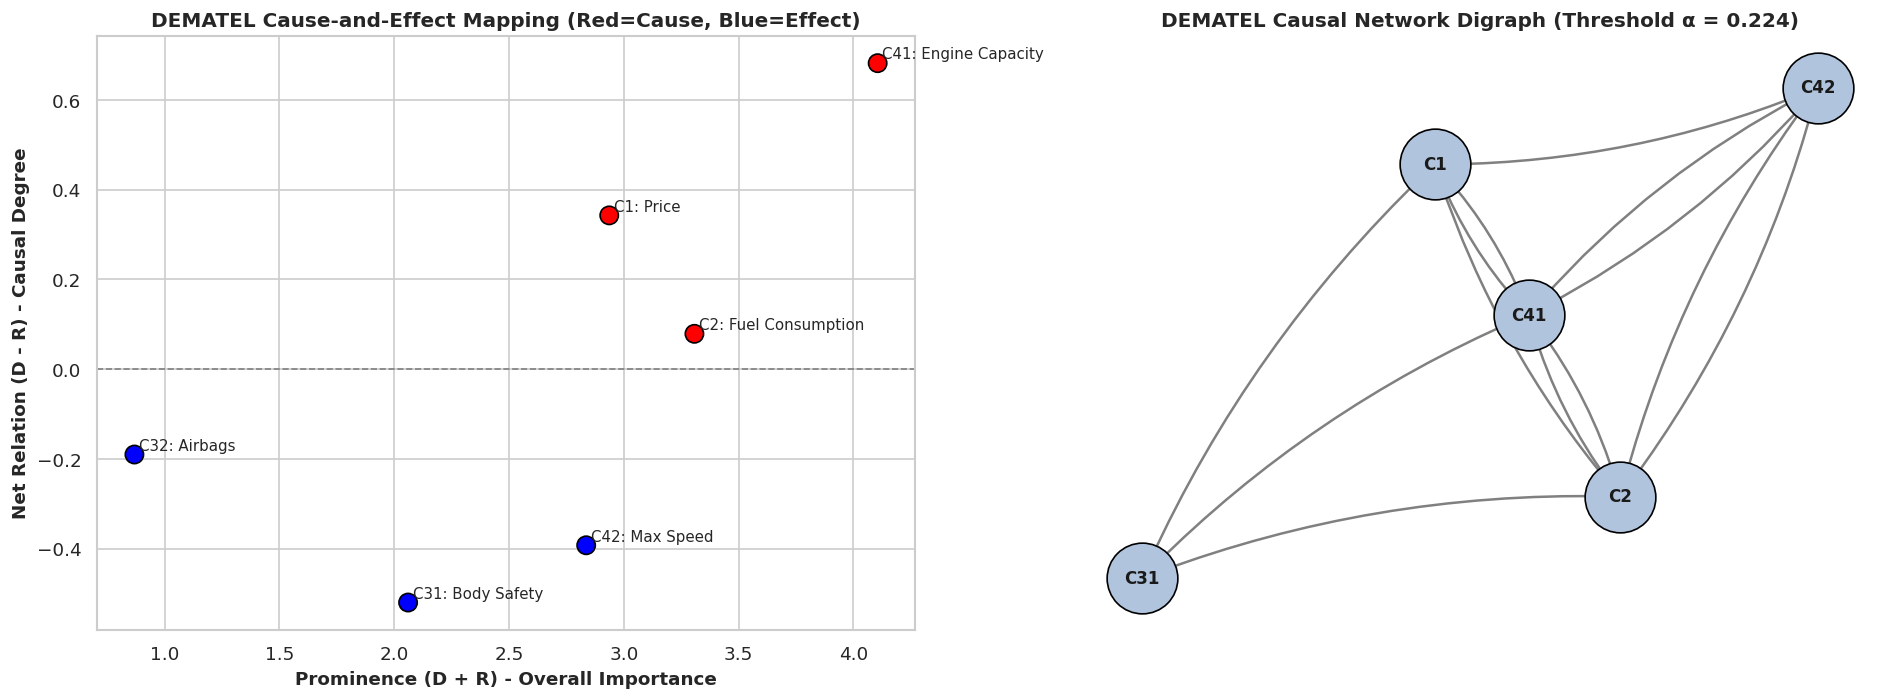

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Causal Scatter Plot (Prominence vs. Relation)
colors = ['red' if val > 0 else 'blue' for val in df_dematel["Net Relation (D - R)"]]
axes[0].scatter(df_dematel["Prominence (D + R)"], df_dematel["Net Relation (D - R)"], c=colors, s=120, edgecolors='black')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=1)

for i, txt in enumerate(sub_criteria):
    axes[0].annotate(txt, (df_dematel["Prominence (D + R)"][i] + 0.02, df_dematel["Net Relation (D - R)"][i] + 0.01), fontsize=9)

axes[0].set_xlabel("Prominence (D + R) - Overall Importance", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Net Relation (D - R) - Causal Degree", fontsize=11, fontweight='bold')
axes[0].set_title("DEMATEL Cause-and-Effect Mapping (Red=Cause, Blue=Effect)", fontsize=12, fontweight='bold')

# 2. Directed Network Graph of Significant Impacts
threshold = np.mean(T)  # Filtering threshold: show only above-average influences
G = nx.DiGraph()

for i, crit_from in enumerate(sub_criteria):
    for j, crit_to in enumerate(sub_criteria):
        if T[i, j] > threshold and i != j:
            G.add_edge(crit_from.split(":")[0], crit_to.split(":")[0], weight=round(T[i, j], 2))

pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=1800, node_color='lightsteelblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, ax=axes[1], font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=axes[1], arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5, connectionstyle="arc3,rad=0.1")
axes[1].set_title(f"DEMATEL Causal Network Digraph (Threshold α = {threshold:.3f})", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Cross-Methodological Benchmark (AHP vs. ANP vs. DEMATEL)


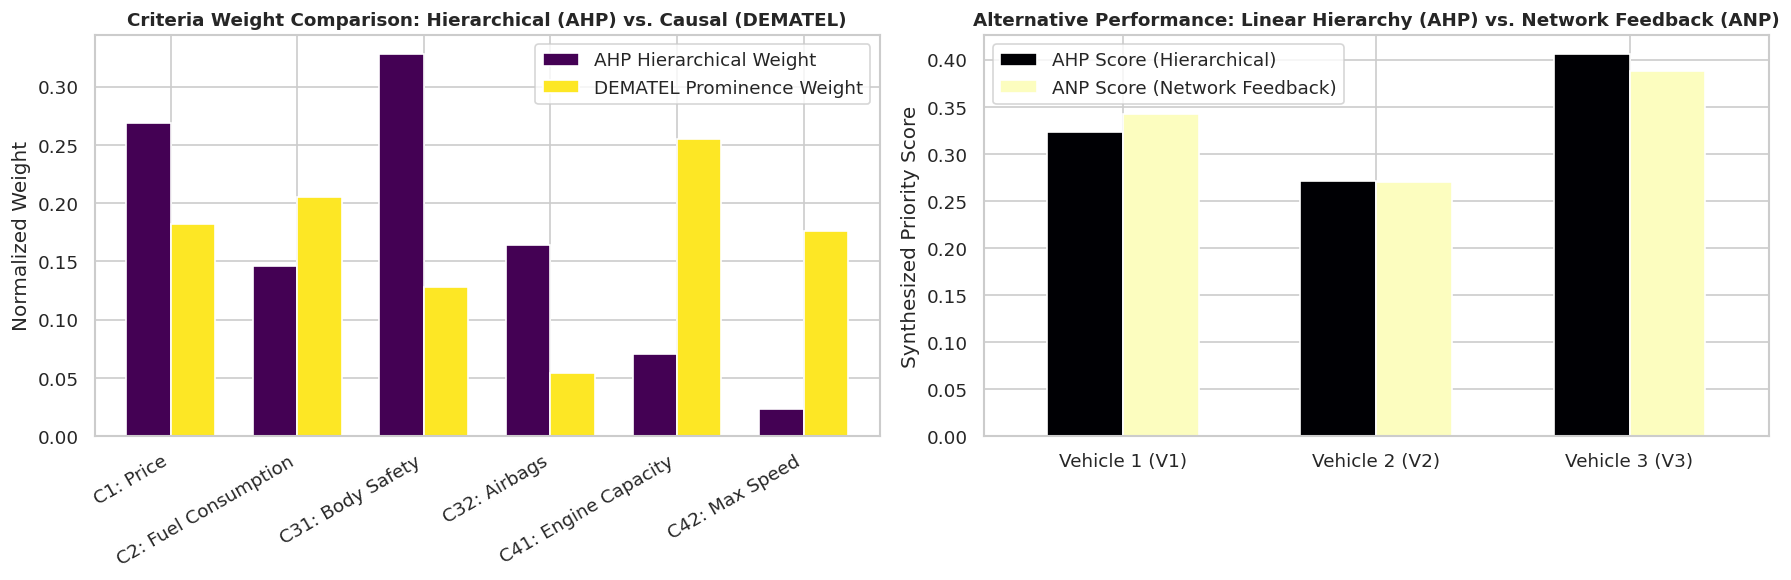

=== FINAL STRATEGIC SELECTION SYNTHESIS ===


,AHP Rank,ANP Rank
Vehicle 1 (V1),NaN,2
Vehicle 2 (V2),NaN,3
Vehicle 3 (V3),NaN,1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Comparison of Criteria Centrality Weights (AHP vs. DEMATEL)
df_crit_comp = pd.DataFrame({
    "AHP Hierarchical Weight": w_global_sub,
    "DEMATEL Prominence Weight": w_dematel
}, index=sub_criteria)

df_crit_comp.plot(kind="bar", ax=axes[0], colormap="viridis", width=0.7)
axes[0].set_title("Criteria Weight Comparison: Hierarchical (AHP) vs. Causal (DEMATEL)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Normalized Weight")
axes[0].set_xticklabels(sub_criteria, rotation=30, ha='right')

# 2. Alternative Rankings: AHP vs. ANP
df_alt_comp = pd.DataFrame({
    "AHP Score (Hierarchical)": df_ahp_results["AHP Composite Score"],
    "ANP Score (Network Feedback)": df_anp_results["ANP Limit Priority"]
}, index=alternatives)

df_alt_comp.plot(kind="bar", ax=axes[1], colormap="magma", width=0.6)
axes[1].set_title("Alternative Performance: Linear Hierarchy (AHP) vs. Network Feedback (ANP)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Synthesized Priority Score")
axes[1].set_xticklabels(alternatives, rotation=0)

plt.tight_layout()
plt.show()

print("=== FINAL STRATEGIC SELECTION SYNTHESIS ===")
pd.DataFrame({
    "AHP Rank": df_ahp_results["AHP Rank"],
    "ANP Rank": df_anp_results["ANP Rank"]
}, index=alternatives)